# LoRA Fine-Tuning on Tiny Shakespeare

Demonstration of Low-Rank Adaptation (LoRA) applied to GPT-2 small,
fine-tuned on the Tiny Shakespeare corpus.

In [1]:
import torch
import matplotlib.pyplot as plt
from PIL import Image

from train.config import TrainingConfig
from model.base_model import LoRAGPT2
from evaluate.evaluator import Evaluator

## Training History

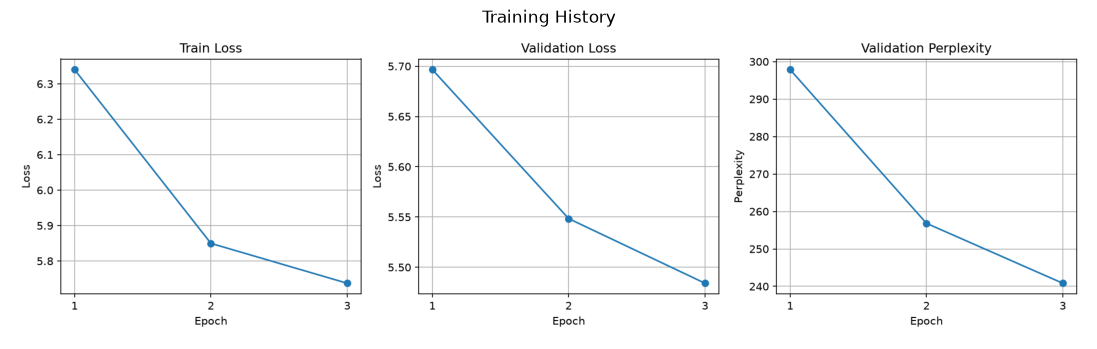

In [2]:
history_path = "outputs/training_history.png"
img = Image.open(history_path)

plt.figure(figsize=(14, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Training History")
plt.show()

## Perplexity Comparison

In [3]:
config = TrainingConfig()
evaluator = Evaluator(config, checkpoint_path="checkpoints/checkpoint_epoch_3.pt")
perplexity_results = evaluator.compare_perplexity()
perplexity_results

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (36059 > 1024). Running this sequence through the model will result in indexing errors


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity comparison (validation set)
Model          Perplexity
--------------------------------------------
Base           10157.3655
Finetuned        240.8267


{'base': 10157.365463770482, 'finetuned': 240.8266545875653}

## Text Generation: Base vs Fine-Tuned

In [4]:
prompts = [
    "To be or not to be",
    "Shall I compare thee",
    "What light through yonder window",
]
evaluator.compare_generation(prompts=prompts)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



Prompt 1
Prompt:
To be or not to be

--- Base model ---
To be or not to be a member of the National Security Council, any person is a foreign national.

(2) The person's nationality is the nationality of another person.

(3) The person's nationality is the nationality of any other person.

(4) The person's nationality is the nationality of any of the persons that are covered by the Convention on the Law of the Sea (the Convention on the Law of the Sea).

(5) A member of the National Security Council shall be treated as a member of the National Security Council at the time of its entry into force.


--- Fine-tuned model ---
To be or not to be
 a,'s and, you the in in and, in
 as, you in with the, and,,,
 it and of you, but, the it you
 and
, the with the like which you do you not
, you
 of with, not, to, the, the of. I.
L:If,,,,,
 have, will,,'d
 the me,, the? I,,, and.
L:But you me, you too

 it as. say you me:,, you,'s




Prompt 2
Prompt:
Shall I compare thee

--- Base model ---
Shall I compare thee with a man who makes a lot of money for a lot of people?"

"No, sir."

"Well, you're in the wrong place."

"Yes, sir."

"Well, I don't know what you were thinking. You were thinking of one of those men who were selling out his estate."

"That's right. I was thinking of one of those men."

"And what about them?"

"The ones who sold their estate in the first place."

"Well, I heard you were thinking of them

--- Fine-tuned model ---
Shall I compare thee
 my for me
 who will all my
 will your my own
 are the. of
A I'd him of man
 a; what should you not but I
 his??
I thee, thy thou
 me thy.
U thy, thee thou, of man
 I in in,;, thou's thee thou I
 thy thou thy
 my, thou me thou thy
 have the not to, me me your
 me thy.
A, thy: my, thy and,,,, thou
 have them as to, for, do
 me;



Prompt 3
Prompt:
What light through yonder window

--- Base model ---
What light through yonder window, and as we drew nearer to the horizon he heard it, and began to sing the song, the song that had been sung upon the night of the storm, and that which was heard in the midst of the storm, which was so great that it had to be said, and then said, and then sang the song, and then sang the song which had been sung upon the night of the storm.

This is what we are told from the account of Joseph Smith's first visit to Missouri when he was a young man; for his first visit to Missouri was in 1825; it

--- Fine-tuned model ---
What light through yonder window
 with thy
 on thy in;
 shall thy him to and.
TTEL:You.! the.:
T:,, you of. I'd not be
 your, would.
T:Why sir I not, I will
.
EL
:Why!
UL:Yes sir sir, I be
 not.
UL
:It you for I
 not sir
UL

:No I
 are as of sir
UL
P
:What sir sir
 you sir
UL

:, sir
U sir sir sir


## Conclusion

LoRA fine-tuning reduced perplexity from ~10,157 (base GPT-2) to ~241
on the Shakespeare validation set — a 42x improvement — while training
only 0.12% of the model parameters (147,456 out of 124M).